# Phase 1 — Data Engineering & EDA
## Blood Vessel Blockage Detection Project

In [6]:
from google.colab import files
read = files.upload()

Saving final.csv to final.csv


In [4]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Load Dataset

In [7]:
df = pd.read_csv('final.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 10)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
0,83.085284,NaN,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0
1,129.254272,0.853361,NaN,35.725150,3.708868,20.324207,117.0,0.840300,0.288642,24.0
2,NaN,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,NaN
4,NaN,NaN,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0


In [9]:
df.tail()

,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
1995,103.959090,NaN,52.901595,36.446258,2.664031,8.429506,92.0,0.901229,0.256953,33.0
1996,117.520483,0.913081,25.115541,35.483461,4.170602,20.302932,113.0,0.989319,0.330228,22.0
1997,97.773481,0.590529,97.495262,36.408942,3.088906,4.906176,72.0,1.578963,0.199275,61.0
1998,113.371780,0.639830,90.547324,37.069778,2.966059,7.913050,73.0,1.442147,0.204199,88.0
1999,110.820671,0.553037,81.713009,37.034659,2.272082,4.763225,81.0,1.662723,0.182513,75.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   peak_systolic_velocity  1937 non-null   float64
 1   resistive_index         1925 non-null   float64
 2   blood_flow_velocity     1941 non-null   float64
 3   avg_temperature         1945 non-null   float64
 4   temperature_difference  1923 non-null   float64
 5   cold_spot_area_percent  1934 non-null   float64
 6   heart_rate              1954 non-null   float64
 7   pulse_amplitude         1958 non-null   float64
 8   pulse_transit_time      1955 non-null   float64
 9   hrv                     1920 non-null   float64
dtypes: float64(10)
memory usage: 156.4 KB


In [11]:
df.describe()

,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
count,1937.000000,1925.000000,1941.000000,1945.000000,1923.000000,1934.000000,1954.000000,1958.000000,1955.000000,1920.000000
mean,107.132332,0.717091,66.134562,36.314478,3.242092,9.763722,81.331116,1.421399,0.248286,51.172917
std,20.010888,0.102169,16.713694,0.480387,0.661218,5.048047,12.206593,0.533961,0.043065,18.178815
min,70.008776,0.550020,25.039128,35.012900,2.000465,3.004286,60.000000,0.306204,0.180036,10.000000
25%,91.642242,0.636325,54.911290,36.010835,2.750826,6.072068,72.000000,1.007092,0.217706,38.000000
50%,105.756839,0.696231,64.919065,36.409185,3.202267,8.145408,80.500000,1.372918,0.239528,50.000000
75%,120.368391,0.791419,77.269940,36.681201,3.684129,12.296196,89.000000,1.782820,0.274314,64.000000
max,159.773470,0.949591,99.994858,37.098756,4.991122,24.975482,119.000000,2.499089,0.379782,89.000000


---
## Step 2 — Missing Value Analysis

**Why median imputation?**
- Medical data is often skewed
- Median is robust to outliers, mean is NOT
- Example: [1,2,3,4,100] → Mean=22 (wrong!), Median=3 (correct!)

In [12]:
# Check missing values
df.isnull().sum()

,0
peak_systolic_velocity,63
resistive_index,75
blood_flow_velocity,59
avg_temperature,55
temperature_difference,77
cold_spot_area_percent,66
heart_rate,46
pulse_amplitude,42
pulse_transit_time,45
hrv,80


In [13]:
# Missing percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct

,0
peak_systolic_velocity,3.15
resistive_index,3.75
blood_flow_velocity,2.95
avg_temperature,2.75
temperature_difference,3.85
cold_spot_area_percent,3.30
heart_rate,2.30
pulse_amplitude,2.10
pulse_transit_time,2.25
hrv,4.00


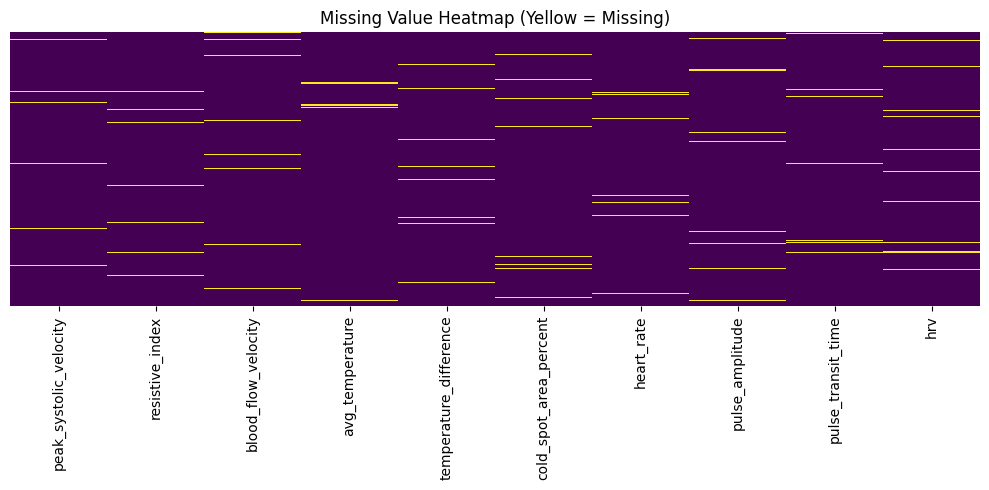

In [14]:
# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

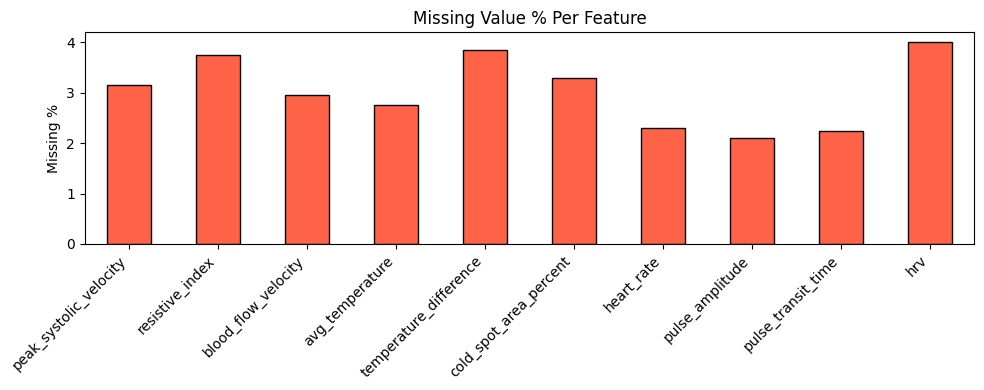

In [15]:
# Missing % bar chart
plt.figure(figsize=(10, 4))
missing_pct.plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Missing Value % Per Feature')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Apply Median Imputation
df = df.fillna(df.median(numeric_only=True))

# Verify no missing values remain
print('Missing values after imputation:', df.isnull().sum().sum())
df.head()

Missing values after imputation: 0


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
0,83.085284,0.696231,96.250183,36.574682,2.407925,6.796991,69.0,2.298226,0.196088,48.0
1,129.254272,0.853361,64.919065,35.725150,3.708868,20.324207,117.0,0.840300,0.288642,24.0
2,105.756839,0.836293,64.084861,35.936101,4.405234,10.418063,86.0,1.151399,0.293710,56.0
3,133.971340,0.688480,69.625238,36.118859,3.347995,8.783595,94.0,1.752332,0.278041,50.0
4,105.756839,0.696231,70.038666,36.995431,2.841834,5.616955,61.0,1.725171,0.212553,78.0


---
## Step 3 — Statistical Analysis

**Skewness Guide:**
- 0 = Perfect symmetric (Normal distribution)
- > 0.7 = Right skewed (tail on right side)
- < -0.7 = Left skewed (tail on left side)
- Skewed features hurt neural network training!

In [17]:
df.describe()

,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,107.089004,0.716309,66.098705,36.317082,3.240558,9.710317,81.312000,1.420381,0.248089,51.126000
std,19.694500,0.100313,16.466481,0.473986,0.648404,4.972428,12.065973,0.528367,0.042598,17.812826
min,70.008776,0.550020,25.039128,35.012900,2.000465,3.004286,60.000000,0.306204,0.180036,10.000000
25%,92.214122,0.639752,55.239870,36.017907,2.769359,6.149594,73.000000,1.013533,0.218795,39.000000
50%,105.756839,0.696231,64.919065,36.409185,3.202267,8.145408,80.500000,1.372918,0.239528,50.000000
75%,119.855510,0.788756,76.916247,36.673085,3.666738,11.990704,89.000000,1.775725,0.273730,63.000000
max,159.773470,0.949591,99.994858,37.098756,4.991122,24.975482,119.000000,2.499089,0.379782,89.000000


In [18]:
# Skewness of each feature
skewness = df.skew()
print('Skewness per feature:')
skewness

Skewness per feature:


,0
peak_systolic_velocity,0.329530
resistive_index,0.347973
blood_flow_velocity,-0.028521
avg_temperature,-0.487093
temperature_difference,0.291815
cold_spot_area_percent,1.003124
heart_rate,0.541876
pulse_amplitude,0.156820
pulse_transit_time,0.684635
hrv,0.183522


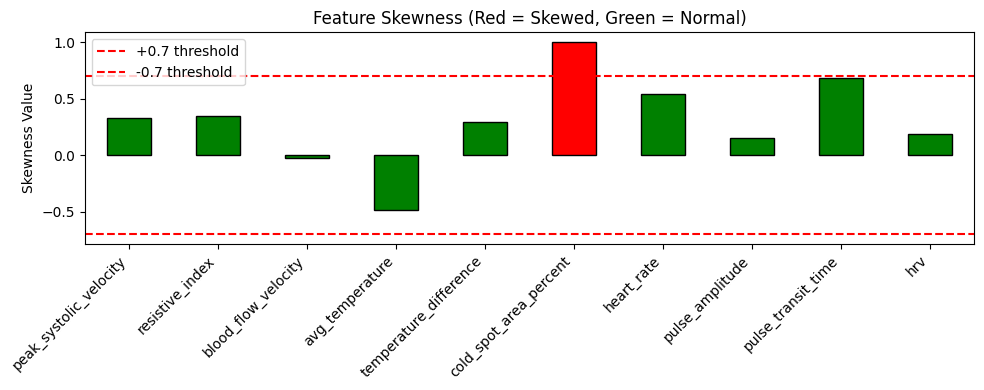

In [19]:
# Visualize skewness
plt.figure(figsize=(10, 4))
colors = ['red' if abs(s) > 0.7 else 'green' for s in skewness]
skewness.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0.7, color='red', linestyle='--', label='+0.7 threshold')
plt.axhline(-0.7, color='red', linestyle='--', label='-0.7 threshold')
plt.title('Feature Skewness (Red = Skewed, Green = Normal)')
plt.ylabel('Skewness Value')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

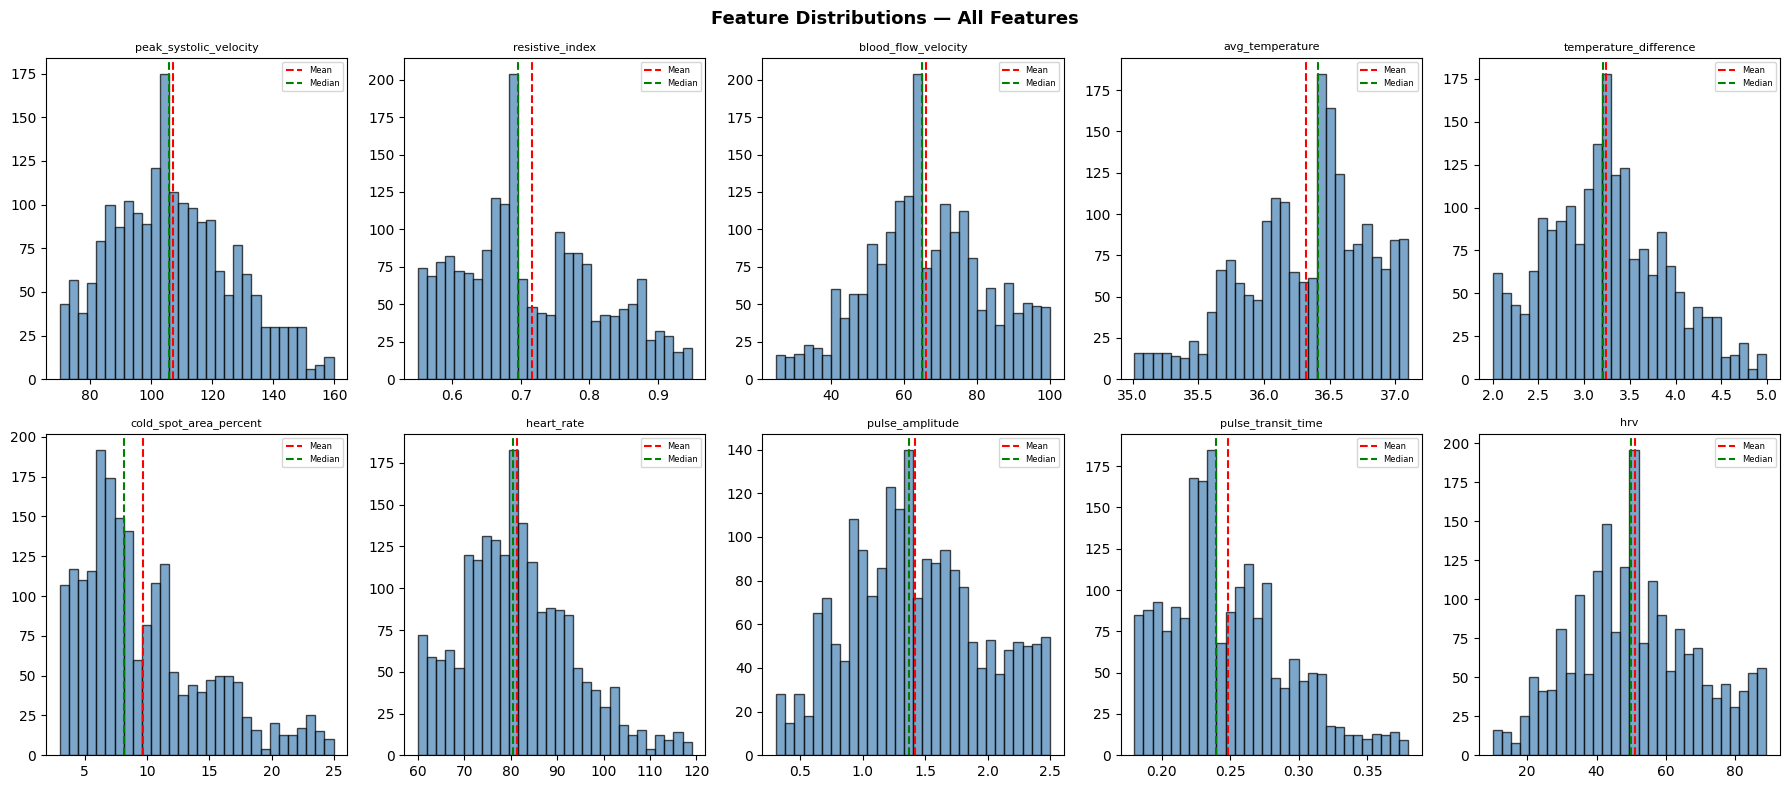

In [20]:
# Distribution plots for all features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=6)

plt.suptitle('Feature Distributions — All Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4 — Outlier Detection

**IQR Method:**
- IQR = Q3 - Q1
- Lower Fence = Q1 - 1.5 * IQR
- Upper Fence = Q3 + 1.5 * IQR
- Outside fence = Outlier

**Why Winsorize not Delete?**
- PSV = 160 cm/s might be REAL blockage data!
- Deleting = losing critical medical information
- Winsorize = cap at fence value, keep the record

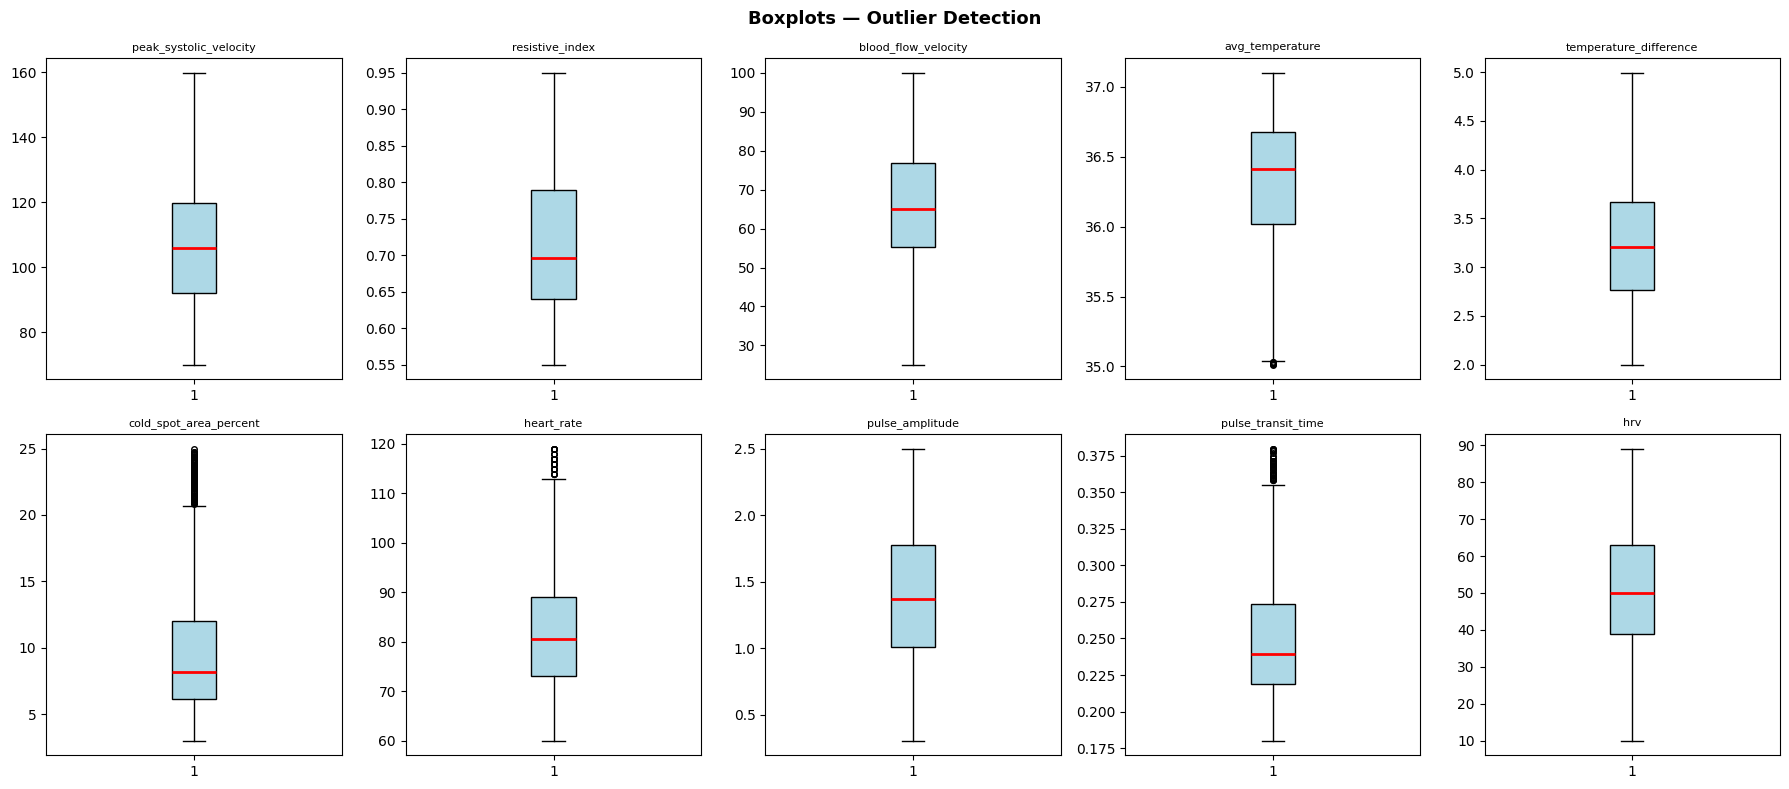

In [21]:
# Boxplots to visualize outliers
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(col, fontsize=8)

plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Count outliers per feature (IQR method)
outlier_counts = {}

for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_series = pd.Series(outlier_counts)
print('Outlier counts per feature:')
outlier_series

Outlier counts per feature:


,0
peak_systolic_velocity,0
resistive_index,0
blood_flow_velocity,0
avg_temperature,7
temperature_difference,0
cold_spot_area_percent,91
heart_rate,31
pulse_amplitude,0
pulse_transit_time,43
hrv,0


In [23]:
# Apply Winsorization (Cap outliers at fence values)
df_clean = df.copy()

for col in df_clean.columns:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print('Winsorization applied!')
print('Shape:', df_clean.shape)
df_clean.describe()

Winsorization applied!
Shape: (2000, 10)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,107.089004,0.716309,66.098705,36.317124,3.240558,9.616208,81.257500,1.420381,0.247844,51.126000
std,19.694500,0.100313,16.466481,0.473871,0.648404,4.731442,11.912111,0.528367,0.041923,17.812826
min,70.008776,0.550020,25.039128,35.035140,2.000465,3.004286,60.000000,0.306204,0.180036,10.000000
25%,92.214122,0.639752,55.239870,36.017907,2.769359,6.149594,73.000000,1.013533,0.218795,39.000000
50%,105.756839,0.696231,64.919065,36.409185,3.202267,8.145408,80.500000,1.372918,0.239528,50.000000
75%,119.855510,0.788756,76.916247,36.673085,3.666738,11.990704,89.000000,1.775725,0.273730,63.000000
max,159.773470,0.949591,99.994858,37.098756,4.991122,20.752369,113.000000,2.499089,0.356134,89.000000


---
## Step 5 — Correlation Analysis

**Correlation Range: -1 to +1**
- +1 = Perfect positive (both increase together)
- -1 = Perfect negative (one increases, other decreases)
- 0  = No relationship

**Medical Insight:**
- PSV ↑ + RI ↑ + ColdSpot ↑ = Blockage likely
- BFV ↓ + PA ↓ + HRV ↓ = Blockage likely

In [24]:
# Correlation matrix
corr_matrix = df_clean.corr()
corr_matrix

,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv
peak_systolic_velocity,1.000000,0.551486,-0.497865,-0.558544,0.453906,0.552123,0.453453,-0.507212,0.539512,-0.428865
resistive_index,0.551486,1.000000,-0.716867,-0.808834,0.671890,0.816469,0.669873,-0.717722,0.798812,-0.631966
blood_flow_velocity,-0.497865,-0.716867,1.000000,0.727148,-0.602653,-0.725879,-0.603878,0.651664,-0.720539,0.565440
avg_temperature,-0.558544,-0.808834,0.727148,1.000000,-0.672731,-0.816181,-0.695320,0.732410,-0.801285,0.632300
temperature_difference,0.453906,0.671890,-0.602653,-0.672731,1.000000,0.672579,0.569559,-0.599312,0.665094,-0.531539
cold_spot_area_percent,0.552123,0.816469,-0.725879,-0.816181,0.672579,1.000000,0.689203,-0.735226,0.801276,-0.628051
heart_rate,0.453453,0.669873,-0.603878,-0.695320,0.569559,0.689203,1.000000,-0.614435,0.673111,-0.518204
pulse_amplitude,-0.507212,-0.717722,0.651664,0.732410,-0.599312,-0.735226,-0.614435,1.000000,-0.725132,0.570716
pulse_transit_time,0.539512,0.798812,-0.720539,-0.801285,0.665094,0.801276,0.673111,-0.725132,1.000000,-0.622862
hrv,-0.428865,-0.631966,0.565440,0.632300,-0.531539,-0.628051,-0.518204,0.570716,-0.622862,1.000000


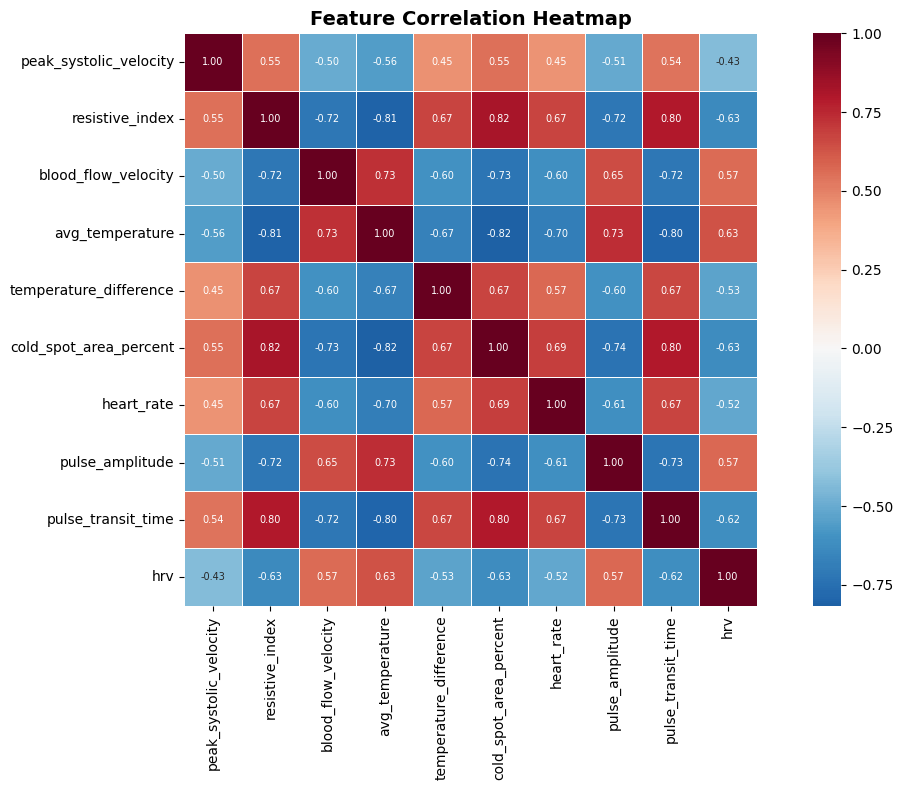

In [25]:
# Heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Top correlated pairs
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset=['Abs Correlation'])
corr_pairs.sort_values('Abs Correlation', ascending=False).head(10)

,Feature 1,Feature 2,Correlation,Abs Correlation
15,resistive_index,cold_spot_area_percent,0.816469,0.816469
35,avg_temperature,cold_spot_area_percent,-0.816181,0.816181
13,resistive_index,avg_temperature,-0.808834,0.808834
38,avg_temperature,pulse_transit_time,-0.801285,0.801285
58,cold_spot_area_percent,pulse_transit_time,0.801276,0.801276
18,resistive_index,pulse_transit_time,0.798812,0.798812
57,cold_spot_area_percent,pulse_amplitude,-0.735226,0.735226
37,avg_temperature,pulse_amplitude,0.732410,0.732410
23,blood_flow_velocity,avg_temperature,0.727148,0.727148
25,blood_flow_velocity,cold_spot_area_percent,-0.725879,0.725879


---
## Step 6 — Feature Engineering

**Why Feature Engineering?**
- Original features ek dimension mein hain
- New features = medical domain knowledge encode karna
- Model ko directly blockage patterns dena
- 10 features → 15 features (5 naye medical features)

In [27]:
# Feature 1: Velocity Ratio
# High PSV + Low BFV = Stenosis (narrow pipe mein pressure high hoti hai)
df_clean['velocity_ratio'] = df_clean['peak_systolic_velocity'] / df_clean['blood_flow_velocity']

# Feature 2: Thermal Stress Index
# High temp diff + Large cold area = Severe ischemia
df_clean['thermal_stress'] = df_clean['temperature_difference'] * df_clean['cold_spot_area_percent']

# Feature 3: Cardiac Load
# High HR + Low PA = Heart overworking due to blockage
df_clean['cardiac_load'] = df_clean['heart_rate'] * df_clean['pulse_amplitude']

# Feature 4: Vascular Resistance Score
# High RI + High PTT = Stiff + Resistant vessel = Blockage
df_clean['vascular_resistance'] = df_clean['resistive_index'] * df_clean['pulse_transit_time']

# Feature 5: Flow Efficiency
# Low BFV / HR = Poor flow per heartbeat = Obstruction
df_clean['flow_efficiency'] = df_clean['blood_flow_velocity'] / df_clean['heart_rate']

print('New features added!')
print('Total features now:', df_clean.shape[1])
df_clean[['velocity_ratio','thermal_stress','cardiac_load','vascular_resistance','flow_efficiency']].describe()

New features added!
Total features now: 15


,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.791239,33.224249,111.551284,0.180890,0.848081
std,0.803102,21.884000,35.646246,0.054148,0.290627
min,0.712304,6.227817,28.550176,0.100594,0.222261
25%,1.233454,16.601986,86.128482,0.136202,0.641377
50%,1.586450,25.875048,110.186782,0.170990,0.823871
75%,2.104052,44.306592,136.232460,0.213755,1.051989
max,6.282313,103.421749,207.281110,0.337980,1.634075


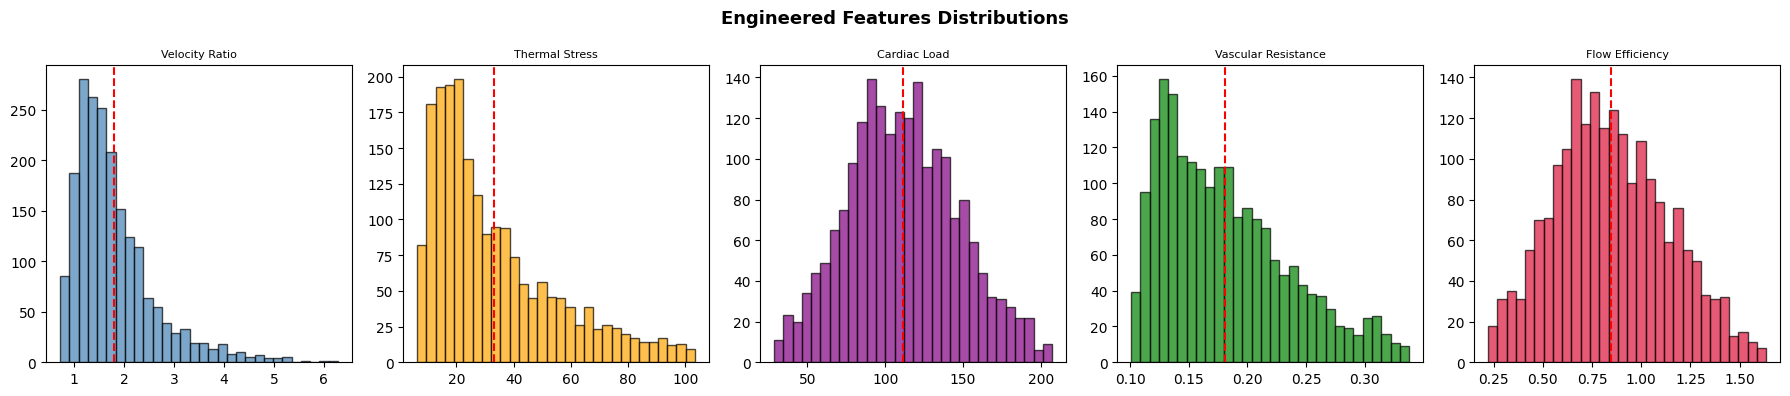

In [28]:
# Engineered features distribution
eng_feats = ['velocity_ratio', 'thermal_stress', 'cardiac_load', 'vascular_resistance', 'flow_efficiency']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = ['steelblue', 'orange', 'purple', 'green', 'crimson']

for i, (col, color) in enumerate(zip(eng_feats, colors)):
    axes[i].hist(df_clean[col], bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=8)
    axes[i].axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5)

plt.suptitle('Engineered Features Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7 — Feature Scaling (StandardScaler)

**Why Scaling is important for Deep Learning?**
- PSV = 70-160 cm/s
- RI = 0.55-0.95 (ratio)
- Different scales → Large scale feature dominates training!

**StandardScaler Formula:**
```
X_scaled = (X - mean) / std
Result: mean = 0, std = 1
```

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.values)

df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)
print('Scaled data shape:', df_scaled.shape)
df_scaled.describe()

Scaled data shape: (2000, 15)


,peak_systolic_velocity,resistive_index,blood_flow_velocity,avg_temperature,temperature_difference,cold_spot_area_percent,heart_rate,pulse_amplitude,pulse_transit_time,hrv,velocity_ratio,thermal_stress,cardiac_load,vascular_resistance,flow_efficiency
count,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,1.065814e-16,-6.874501e-16,7.815970e-17,-7.226220e-15,-1.456613e-16,2.948752e-16,5.808687e-16,1.776357e-18,-5.968559e-16,1.421085e-16,3.375078e-17,2.025047e-16,5.595524e-17,-9.059420e-17,-8.704149e-17
std,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.883242e+00,-1.658121e+00,-2.494148e+00,-2.706022e+00,-1.913011e+00,-1.397793e+00,-1.784975e+00,-2.109244e+00,-1.617821e+00,-2.309363e+00,-1.343796e+00,-1.233924e+00,-2.329049e+00,-1.483285e+00,-2.153878e+00
25%,-7.554699e-01,-7.633762e-01,-6.596158e-01,-6.315905e-01,-7.268880e-01,-7.328592e-01,-6.933754e-01,-7.702021e-01,-6.930776e-01,-6.809157e-01,-6.947125e-01,-7.597523e-01,-7.133755e-01,-8.255035e-01,-7.114098e-01
50%,-6.765838e-02,-2.002070e-01,-7.165680e-02,1.943235e-01,-5.907015e-02,-3.109344e-01,-6.360665e-02,-8.985191e-02,-1.984109e-01,-6.322869e-02,-2.550618e-01,-3.359092e-01,-3.828854e-02,-1.828910e-01,-8.332265e-02
75%,6.483891e-01,7.223900e-01,6.571075e-01,7.513642e-01,6.574393e-01,5.019801e-01,6.501313e-01,6.727003e-01,6.176298e-01,6.667650e-01,3.896032e-01,5.065397e-01,6.925652e-01,6.070921e-01,7.017911e-01
max,2.675754e+00,2.326125e+00,2.059009e+00,1.649873e+00,2.700480e+00,2.354239e+00,2.665391e+00,2.042100e+00,2.583691e+00,2.126752e+00,5.593555e+00,3.208511e+00,2.686223e+00,2.901843e+00,2.705150e+00


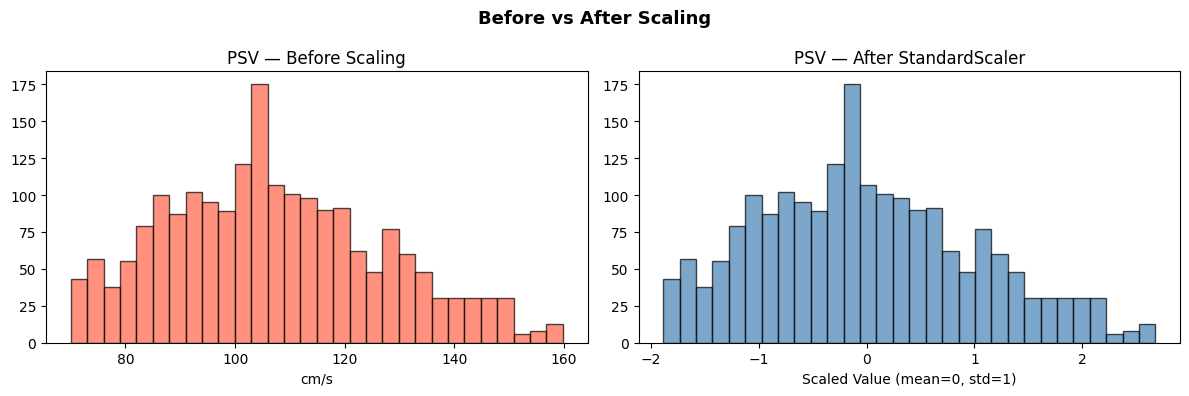

In [30]:
# Before vs After scaling comparison (PSV feature)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['peak_systolic_velocity'], bins=30,
             color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('PSV — Before Scaling')
axes[0].set_xlabel('cm/s')

axes[1].hist(df_scaled['peak_systolic_velocity'], bins=30,
             color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('PSV — After StandardScaler')
axes[1].set_xlabel('Scaled Value (mean=0, std=1)')

plt.suptitle('Before vs After Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

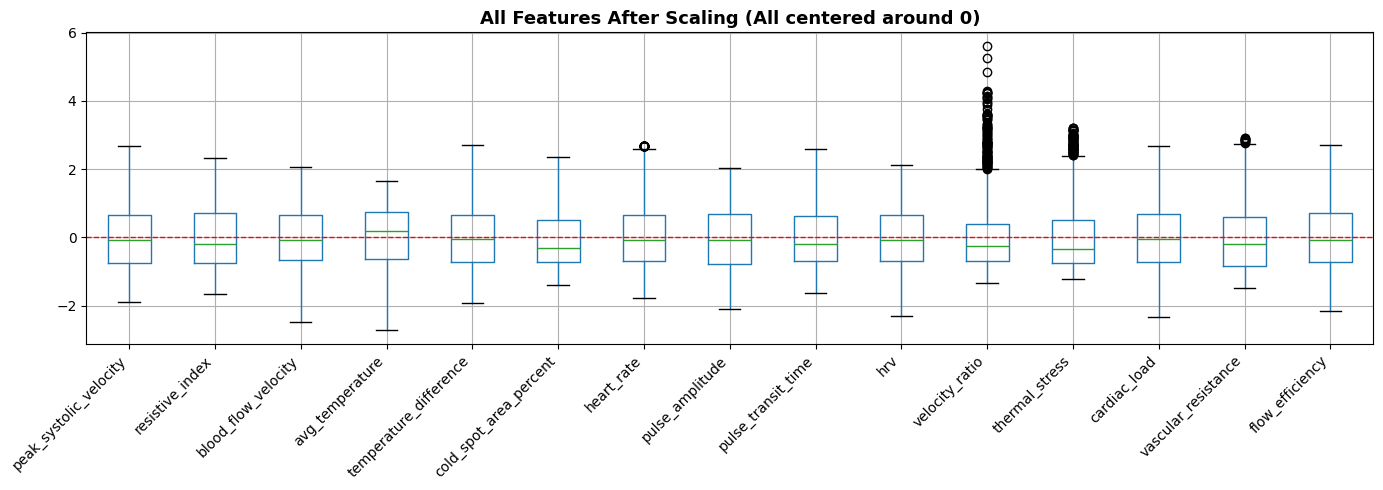

In [31]:
# All features scaled boxplot
plt.figure(figsize=(14, 5))
df_scaled.boxplot(figsize=(14, 5))
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('All Features After Scaling (All centered around 0)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## Step 8 — Save Cleaned Data

In [32]:
import pickle

# Save clean data
df_clean.to_csv('phase1_clean_data.csv', index=False)

# Save scaled numpy array
np.save('phase1_X_scaled.npy', X_scaled)

# Save scaler for reuse in Phase 2-7
with open('phase1_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
feature_names = df_clean.columns.tolist()
with open('phase1_feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print('Files saved:')
print('  phase1_clean_data.csv')
print('  phase1_X_scaled.npy')
print('  phase1_scaler.pkl')
print('  phase1_feature_names.pkl')

Files saved:
  phase1_clean_data.csv
  phase1_X_scaled.npy
  phase1_scaler.pkl
  phase1_feature_names.pkl


### Option 1: Download files to your local machine

In [34]:
from google.colab import files

# List of files to download
files_to_download = [
    'phase1_clean_data.csv',
    'phase1_X_scaled.npy',
    'phase1_scaler.pkl',
    'phase1_feature_names.pkl'
]

for file_name in files_to_download:
    try:
        files.download(file_name)
        print(f'Downloaded: {file_name}')
    except FileNotFoundError:
        print(f'Error: {file_name} not found. Please ensure the cell that saves these files was executed.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase1_clean_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: phase1_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase1_feature_names.pkl


### Option 2: Save files to your Google Drive (recommended for persistence)

First, you need to mount your Google Drive to your Colab environment. You will be prompted to authorize this connection.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

Once your Drive is mounted, you can copy the saved files to a folder in your Google Drive. For example, let's create a folder named `my_colab_project_files` in your Drive and copy the files there.

In [ ]:
import shutil
import os

# Define the target directory in Google Drive
drive_path = '/content/drive/MyDrive/my_colab_project_files'

# Create the directory if it doesn't exist
os.makedirs(drive_path, exist_ok=True)

# List of files to copy from current directory to Google Drive
files_to_copy = [
    'phase1_clean_data.csv',
    'phase1_X_scaled.npy',
    'phase1_scaler.pkl',
    'phase1_feature_names.pkl'
]

print(f"Copying files to: {drive_path}")
for file_name in files_to_copy:
    source_path = os.path.join('.', file_name) # Assuming files are in the current working directory
    destination_path = os.path.join(drive_path, file_name)
    try:
        shutil.copy(source_path, destination_path)
        print(f'Copied {file_name} to Google Drive.')
    except FileNotFoundError:
        print(f'Error: {file_name} not found in the current Colab session. Please ensure the cell that saves these files was executed.')

print('All specified files copied to Google Drive.')

---
## Phase 1 Summary

In [33]:
print('========================================')
print('  PHASE 1 — COMPLETE')
print('========================================')
print(f'Original features  : 10')
print(f'Engineered features: 5')
print(f'Total features     : {df_clean.shape[1]}')
print(f'Total patients     : {df_clean.shape[0]}')
print(f'Missing values     : 0 (median imputed)')
print(f'Outliers           : 0 (winsorized)')
print(f'Scaling            : StandardScaler applied')
print('========================================')
print('  NEXT → PHASE 2: Label Generation')
print('========================================')

  PHASE 1 — COMPLETE
Original features  : 10
Engineered features: 5
Total features     : 15
Total patients     : 2000
Missing values     : 0 (median imputed)
Outliers           : 0 (winsorized)
Scaling            : StandardScaler applied
  NEXT → PHASE 2: Label Generation
